✅ 2D Asset kaydedildi: ../../../assets\45_lotka_2d.png


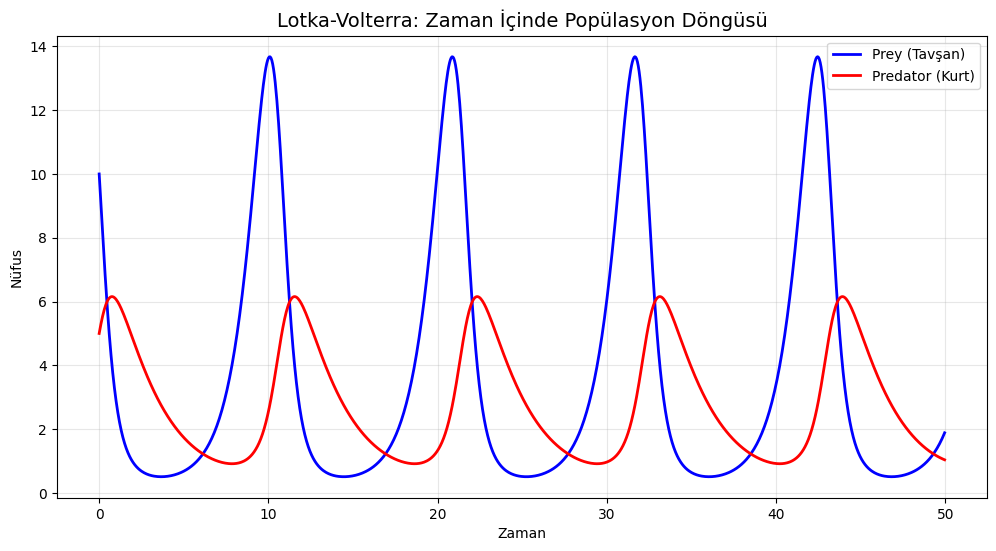

✅ 3D Asset kaydedildi: ../../../assets\45_lotka_3d.png


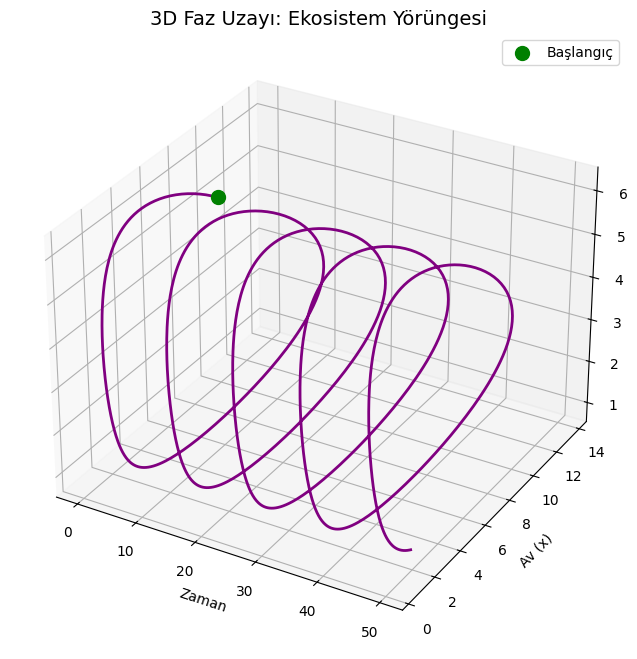

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

def run_lotka_volterra_master():
    # --- 🎯 SENİN YOLUN (FIXED ASSET PATH) ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Model Parametreleri
    alpha, beta = 1.1, 0.4  # Av (Prey) parametreleri
    delta, gamma = 0.1, 0.4 # Avcı (Predator) parametreleri
    
    t_end = 50
    dt = 0.05
    t_vals = np.arange(0, t_end, dt)

    # Bağlı Diferansiyel Denklemler
    def dXdt(x, y): return alpha * x - beta * x * y
    def dYdt(x, y): return delta * x * y - gamma * y

    # RK4 Çözücü (Coupled System için)
    x = np.zeros(len(t_vals)); y = np.zeros(len(t_vals))
    x[0], y[0] = 10, 5 # Başlangıç: 10 Tavşan, 5 Kurt

    for i in range(len(t_vals)-1):
        # RK4 Katsayıları - x için
        kx1 = dXdt(x[i], y[i])
        ky1 = dYdt(x[i], y[i])
        
        kx2 = dXdt(x[i] + dt*kx1/2, y[i] + dt*ky1/2)
        ky2 = dYdt(x[i] + dt*kx1/2, y[i] + dt*ky1/2)
        
        kx3 = dXdt(x[i] + dt*kx2/2, y[i] + dt*ky2/2)
        ky3 = dYdt(x[i] + dt*kx2/2, y[i] + dt*ky2/2)
        
        kx4 = dXdt(x[i] + dt*kx3, y[i] + dt*ky3)
        ky4 = dYdt(x[i] + dt*kx3, y[i] + dt*ky3)
        
        x[i+1] = x[i] + (dt/6)*(kx1 + 2*kx2 + 2*kx3 + kx4)
        y[i+1] = y[i] + (dt/6)*(ky1 + 2*ky2 + 2*ky3 + ky4)

    # --- 📸 ASSET 1: 2D TIME SERIES (45_lotka_2d.png) ---
    fig1 = plt.figure(figsize=(12, 6))
    plt.plot(t_vals, x, 'b-', label='Prey (Tavşan)', lw=2)
    plt.plot(t_vals, y, 'r-', label='Predator (Kurt)', lw=2)
    plt.title("Lotka-Volterra: Zaman İçinde Popülasyon Döngüsü", fontsize=14)
    plt.xlabel("Zaman"); plt.ylabel("Nüfus")
    plt.legend(); plt.grid(alpha=0.3)
    
    plt.savefig(os.path.join(asset_path, '45_lotka_2d.png'), dpi=300)
    print(f"✅ 2D Asset kaydedildi: {asset_path}\\45_lotka_2d.png")
    plt.show()

    # --- 📸 ASSET 2: 3D PHASE SPACE (45_lotka_3d.png) ---
    fig2 = plt.figure(figsize=(10, 8))
    ax3d = fig2.add_subplot(111, projection='3d')
    
    # 3D düzlemde (Zaman, Av, Avcı) ilişkisi
    ax3d.plot(t_vals, x, y, color='purple', lw=2)
    ax3d.set_title("3D Faz Uzayı: Ekosistem Yörüngesi", fontsize=14)
    ax3d.set_xlabel('Zaman'); ax3d.set_ylabel('Av (x)'); ax3d.set_zlabel('Avcı (y)')
    
    # Başlangıç noktasını işaretle
    ax3d.scatter(t_vals[0], x[0], y[0], color='green', s=100, label='Başlangıç')
    ax3d.legend()

    plt.savefig(os.path.join(asset_path, '45_lotka_3d.png'), dpi=300)
    print(f"✅ 3D Asset kaydedildi: {asset_path}\\45_lotka_3d.png")
    plt.show()

if __name__ == "__main__":
    run_lotka_volterra_master()
